# TPL Spacing Calculations

## 1. Importing / Installing Packages

In [1]:
import os

import pandas as pd
pd.set_option('display.max_columns', None)

from src.utils import (DatabricksConfig, get_logger, compute_bg_rcat, reorder_columns, 
                       drop_duplicates_keep_max_last_prod, read_csv_with_mapper, 
                       standardize_column_names, add_producing_months, calculate_cumulative_volumes_by_period)

from src.well_data import WellDataLoader, GeoSurveyProcessor, WellSpacingCalculator, DirectionalBenchNeighbors, FloatingSectionWPS, BoxSpec, CorridorSpec, AvgSpacingCalculator

import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'svg' # Configuring inline backend to use SVG format for figures

## 2. Initializing Logger

In [2]:
logger = get_logger(name="spacing_tpl", log_to_console=False, level="INFO", propagate=True)

## 3. Importing Well Header and Directional Survey

### 3.1 Initializing Database Configuration 

In [3]:
cfg = DatabricksConfig(
server_hostname="adb-3250236208859616.16.azuredatabricks.net",
http_path="/sql/1.0/warehouses/0cf5fe590cb7b313",
token=os.environ["databricks_token"],
catalog="bronze",
schema="enverus",
)

loader = WellDataLoader(db_cfg=cfg,
                        logger=logger, directional_source="enverus")

### 3.2 Importing Header

In [4]:
# header_query = """
#     SELECT
#         API_UWI_14_Unformatted AS uwi,
#         API_UWI_12_Unformatted AS uwi12,
#         LeaseName AS lease_name,
#         WellName AS well_name,
#         ENVOperator AS operator,
#         ENVInterval AS bench,
#         SpudDate as spud_date,
#         CompletionDate AS comp_date,
#         FirstProdDate AS first_prod_date,
#         LastProducingMonth as last_prod_date,
#         Trajectory AS hole_direction,
#         ENVWellStatus as well_status,
#         LateralLength_FT AS lateral_length_ft,
#         Latitude AS surface_lat,
#         Longitude AS surface_lon,
#         FluidIntensity_BBLPerFT AS fluid_intensity_bbl_per_ft,
#         ProppantIntensity_LBSPerFT AS proppant_intensity_lbs_per_ft
#     FROM bronze.enverus.wells
#     WHERE 
#         StateProvince = 'TX'
#             AND
#         County IN ('MIDLAND', 'HOWARD', 'MARTIN', 'GLASSCOCK')
#             AND
#         ENVInterval IS NOT NULL
#             AND
#         Trajectory = 'HORIZONTAL'
# """

header_col_map = {
    # SOURCE COLUMN NAME  -> CANONICAL NAME
    "uwi": "uwi",
    "uwi12": "uwi12",
    "lease_name": "lease_name",
    "well_name": "well_name",
    "operator": "operator",
    "bench": "bench",
    "spud_date": "spud_date",
    "comp_date": "comp_date",
    "first_prod_date": "first_prod_date",
    "last_prod_date": "last_prod_date",
    "hole_direction": "hole_direction",
    "well_status": "well_status",
    "lateral_length_ft": "lateral_length_ft",
    "surface_lat": "surface_lat",
    "surface_lon": "surface_lon",
    "fluid_intensity_bbl_per_ft": "fluid_intensity_bbl_per_ft",
    "proppant_intensity_lbs_per_ft": "proppant_intensity_lbs_per_ft",
}

df_header_db = loader.get_header_data(source=r"C:\Users\ApoorvaSaxen_ct6z7vh\OneDrive - Bandera Group\Desktop\Project AP\05. Spacing Study\02. TPL\01. Well Header\well_header_raw.csv",
    column_map=header_col_map,
    dtype_map={"uwi12": "string", "uwi": "string"},)

### 3.3 Computing BG Reserve Category

In [5]:
df_header_db['bg_rcat'] = compute_bg_rcat(df_header_db, 
                col_map={
    "status": "well_status",
    "last_prod": "last_prod_date",
    "spud": "spud_date",
    "comp": "comp_date"
                        },
    utc=True
)

df_header_db = reorder_columns(df_header_db,columns_to_move=['bg_rcat'],reference_column='bench')

In [6]:
# Remove duplicates, keeping the one with the max last production date
df_header_db = drop_duplicates_keep_max_last_prod(df_header_db).copy()

### 3.4 Filtering Header to include PDP, WOP, PDSI and DUC Rsv Categories

In [7]:
df_header_rsv_filter = df_header_db[df_header_db['bg_rcat'].isin(["1PDP", "1WOP", "1PDSI", "2DUC"])].reset_index(drop=True).copy()

### 3.5 Filtering Header to include PDP, WOP, PDSI and DUC Rsv Categories

In [8]:
uwis_12_list = df_header_rsv_filter['uwi12'].astype(str).dropna().unique().tolist()

In [9]:
# directional_query = """
#     SELECT
#         API_UWI_12_Unformatted AS uwi12,
#         MeasuredDepth_FT AS md,
#         TVD_FT AS tvd,
#         Inclination_DEG AS inclination,
#         Azimuth_DEG AS azimuth,
#         Latitude AS latitude,
#         Longitude AS longitude,
#         E_W AS `deviation_E/W`,
#         N_S AS `deviation_N/S`
#     FROM bronze.enverus.fulldirectionalsurvey
#     WHERE 
#         API_UWI_12_Unformatted IN :uwis_12
#     ORDER BY 
#         API_UWI_12_Unformatted, MeasuredDepth_FT;
# """

# df_directional_db = loader.get_directional_data(directional_query=directional_query, 
#                                                 directional_params={"uwis_12": uwis_12_list})

directional_col_map = {
    # SOURCE COLUMN NAME  -> CANONICAL NAME
    "API_UWI_12_Unformatted": "uwi12",
    "MeasuredDepth_FT": "md",
    "TVD_FT": "tvd",
    "Inclination_DEG": "inclination",
    "Azimuth_DEG": "azimuth",
    "Latitude": "latitude",
    "Longitude": "longitude",
    "E_W": "deviation_E/W",
    "N_S": "deviation_N/S",
}

df_directional_db = loader.get_directional_data(
    source=r"C:\Users\ApoorvaSaxen_ct6z7vh\OneDrive - Bandera Group\Desktop\Project AP\05. Spacing Study\02. TPL\02. Directional Survey\DS_from_DB_raw.csv",
    column_map=directional_col_map,
    dtype_map={"uwi12": "string"},
)

### 3.6 Merging UWI from header to directional survey dataframe

In [10]:
df_directional_db_merge_uwi = df_directional_db.merge(df_header_rsv_filter[['uwi','uwi12']].drop_duplicates(subset=['uwi12'], keep='first'), on='uwi12', how='left')

df_directional_db_merge_uwi = reorder_columns(df_directional_db_merge_uwi,columns_to_move=['uwi'],reference_column='uwi12')

## 4. Computing UTM Coordinates

In [11]:
geo = GeoSurveyProcessor(logger=logger) # Initialize GeoSurveyProcessor

df_utm = geo.compute_utm_coordinates(df=df_directional_db_merge_uwi, force_utm_zone=13)

# Filter the DataFrame to get only the lateral sections after the heel point
df_utm_lateral = geo.filter_after_heel_point(df=df_utm)

# Calculate midpoints for lateral wells
df_midpoints_lateral = geo.get_heel_toe_midpoints_latlon(df=df_utm_lateral)

In [52]:
df_midpoints_lateral

,uwi,heel_lat,heel_lon,toe_lat,toe_lon,mid_Lat,mid_Lon
0,42173006330100,31.701248,-101.687326,31.703553,-101.688482,31.702401,-101.687904
1,42173319360100,31.788725,-101.774347,31.793615,-101.777695,31.791170,-101.776021
2,42173322810000,31.928968,-101.660937,31.928940,-101.661703,31.928954,-101.661320
3,42173328120000,31.944910,-101.615696,31.944854,-101.619149,31.944882,-101.617423
4,42173334750000,31.876105,-101.429001,31.866150,-101.426271,31.871128,-101.427636
...,...,...,...,...,...,...,...
18654,42329480450000,31.654645,-101.998331,31.621701,-101.987558,31.638173,-101.992945
18655,42329480460000,31.655311,-101.995278,31.622412,-101.984521,31.638861,-101.989900
18656,42329480520000,32.056232,-102.048847,32.035854,-102.044397,32.046043,-102.046622
18657,42329480530000,31.879568,-102.023395,31.933244,-102.040560,31.906406,-102.031977


## 5. Spacing Algorithm

### 5.1 Filtering well header data whose directional surveys are missing

In [13]:
missing_uwi = set(df_header_rsv_filter['uwi12']) - set(df_utm_lateral['uwi12'])
print(f"Number of missing UWI from header dataframe: {len(missing_uwi)}")
# list(missing_uwi)

Number of missing UWI from header dataframe: 154


In [14]:
df_header_filter_for_spacing = df_header_rsv_filter[~df_header_rsv_filter['uwi12'].isin(missing_uwi)].reset_index(drop=True).copy()

### 5.1 Filtering well header data whose directional surveys are missing from, UTM Lateral

In [15]:
# of UWIs in header filter not present in UTM lateral data
list(set(df_header_filter_for_spacing['uwi12']) - set(df_utm_lateral[df_utm_lateral["uwi12"].isin(df_header_filter_for_spacing["uwi12"].unique())]["uwi12"]))

[]

### 5.1 Calculate Spacing

In [16]:
# Create WellSpacingCalculator instance
spacing_stats_ik = WellSpacingCalculator(trajectories=df_utm_lateral[df_utm_lateral["uwi12"].isin(df_header_filter_for_spacing["uwi12"].unique())])

In [ ]:
# Calculate spacing statistics with specified parameters and save the results in parquet files
# spacing_stats_ik._calculate_spacing_statistics(
#     batch_size=500_000,
#     max_distance_miles=3.0,
#     save_batches_dir=r"C:\Users\ApoorvaSaxen_ct6z7vh\OneDrive - Bandera Group\Desktop\Project AP\05. Spacing Study\02. TPL\04. Spacing Results",
#     max_crossline_ft=10_560
# )

🚀 Calculating Spacing (Parallel): |████████████████████████████████████████| 100% 8/8 [00:00<00:00]


✅ All batches saved to C:\Users\ApoorvaSaxen_ct6z7vh\OneDrive - Bandera Group\Desktop\Project AP\05. Spacing Study\02. TPL\04. Spacing Results


### 5.2 Read Calculated and Saved Spacing Results from Parquet Files

In [18]:
df_spacing_ik = spacing_stats_ik._load_saved_batches(
    batch_folder=r"C:\Users\ApoorvaSaxen_ct6z7vh\OneDrive - Bandera Group\Desktop\Project AP\05. Spacing Study\02. TPL\04. Spacing Results"
)

🔍 Found 8 batch files. Loading and combining...
✅ Loaded 3,125,763 rows from all batches.


### 5.3 Filtering rows where 'reject_reason' column is empty

In [19]:
# Filter out rejected spacing calculations
df_spacing_ik_filt = df_spacing_ik[df_spacing_ik["reject_reason"]==""].reset_index(drop=True).copy()

### 5.4 Merging bench from header data with spacing ik filtered dataframe

In [20]:
bench_map = df_header_filter_for_spacing.set_index("uwi")["bench"]

df_spacing_ik_filt["bench_i"] = df_spacing_ik_filt["well_i"].map(bench_map)
df_spacing_ik_filt["bench_k"] = df_spacing_ik_filt["well_k"].map(bench_map)

df_spacing_ik_filt = reorder_columns(df=df_spacing_ik_filt, columns_to_move=['bench_i', 'bench_k'], reference_column='well_k')
df_spacing_ik_filt = reorder_columns(df=df_spacing_ik_filt, 
                                        columns_to_move=['direction_to_k_from_i_axis','overlap_pct_i', 'overlap_pct_k','overlap_len_common_ft', 'LL_i', 'LL_k'], 
                                        reference_column='3D_dist')

In [51]:
df_spacing_ik_filt

,well_i,well_k,bench_i,bench_k,horizontal_dist,horizontal_dist_median,vertical_dist,3D_dist,direction_to_k_from_i_axis,overlap_pct_i,overlap_pct_k,overlap_len_common_ft,LL_i,LL_k,drill_direction_i,drill_direction_k,n_samples,dy_p5,angle_deg,pair_alignment,min_distance_ft,mean_windowed_ft,reject_reason,direction_axis,direction_axis_confidence,direction_axis_distribution,axis_forced,proj_coverage_i_pct,contact_threshold_ft,contact_len_i_ft,contact_pct_i,contact_len_i_interior_ft,contact_pct_i_interior,contact_len_i_ft_T300,contact_pct_i_T300,contact_len_i_interior_ft_T300,contact_pct_i_interior_T300,horizontal_crossline_mean_ft,hz_effective,hz_basis,3D_dist_effective
0,42173006330100,42173393640000,ABOVE UPPER SPRABERRY,WOODFORD AND BELOW,1388.508559,1372.585829,6305.148762,6456.226215,E,1.000000,0.094486,917.221153,917.221153,9707.532960,NS,NS,10.0,1347.191297,7.421368,parallel_like,NaN,NaN,,EW,1.0,"E:1.00,W:0.00",True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1388.508559,1388.508559,crossline_mean,6456.226215
1,42173006330100,42173393660000,ABOVE UPPER SPRABERRY,WOLFCAMP A,3176.285659,3164.241135,4244.765450,5301.586961,E,1.000000,0.001410,917.221153,917.221153,650604.306573,NS,NS,10.0,3127.518939,6.048709,parallel_like,NaN,NaN,,EW,1.0,"E:1.00,W:0.00",True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3176.285659,3176.285659,crossline_mean,5301.586961
2,42173006330100,42173393720000,ABOVE UPPER SPRABERRY,WOODFORD AND BELOW,4033.146518,4017.223788,5917.802012,7161.469925,E,1.000000,0.081848,917.221153,917.221153,11206.363178,NS,NS,10.0,3989.344253,8.195466,parallel_like,NaN,NaN,,EW,1.0,"E:1.00,W:0.00",True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4033.146518,4033.146518,crossline_mean,7161.469925
3,42173006330100,42173393760000,ABOVE UPPER SPRABERRY,WOODFORD AND BELOW,4923.223935,4907.301205,6304.882351,7999.354685,E,1.000000,0.090534,917.221153,917.221153,10131.271871,NS,NS,10.0,4879.386916,7.832513,parallel_like,NaN,NaN,,EW,1.0,"E:1.00,W:0.00",True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4923.223935,4923.223935,crossline_mean,7999.354685
4,42173006330100,42173393770000,ABOVE UPPER SPRABERRY,WOODFORD AND BELOW,5831.247928,5815.325198,5921.919361,8310.991596,E,1.000000,0.082784,917.221153,917.221153,11079.734438,NS,NS,10.0,5787.410909,7.415788,parallel_like,NaN,NaN,,EW,1.0,"E:1.00,W:0.00",True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5831.247928,5831.247928,crossline_mean,8310.991596
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1815447,42329480970000,42329474190000,WOODFORD AND BELOW,WOLFCAMP B LOWER,10519.417955,10519.417955,2528.602197,10819.056483,W,0.000456,0.000574,6.073527,13309.003534,10589.868057,NS,NS,2.0,10519.184342,5.094648,parallel_like,NaN,NaN,,EW,1.0,"E:0.00,W:1.00",True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10519.417955,10519.417955,crossline_mean,10819.056483
1815448,42329480970000,42329474200000,WOODFORD AND BELOW,JO MILL,10492.514022,10492.514022,3629.972197,11102.682048,W,0.000368,0.000453,4.896532,13309.003534,10813.704549,NS,NS,2.0,10492.459185,2.978437,parallel_like,NaN,NaN,,EW,1.0,"E:0.00,W:1.00",True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10492.514022,10492.514022,crossline_mean,11102.682048
1815449,42329480970000,42329475270000,WOODFORD AND BELOW,BARNETT,9235.050182,9233.714913,384.002197,9243.030322,W,0.649380,0.713730,8642.600012,13309.003534,12109.055802,NS,NS,87.0,9220.856121,0.262736,parallel_like,NaN,NaN,,EW,1.0,"E:0.00,W:1.00",True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9235.050182,9235.050182,crossline_mean,9243.030322
1815450,42329480970000,42329475290000,WOODFORD AND BELOW,BARNETT,7953.223761,7948.360196,415.067197,7964.047273,W,0.635334,0.760705,8455.656409,13309.003534,11115.549029,NS,NS,85.0,7910.736530,0.452000,parallel_like,NaN,NaN,,EW,1.0,"E:0.00,W:1.00",True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7953.223761,7953.223761,crossline_mean,7964.047273


## 6. One-Lines

### 6.1 Running oneline

In [22]:
nb = DirectionalBenchNeighbors()

one_line_summary = nb.summarize(
    spacing_df=df_spacing_ik_filt, 
    header_df=df_header_filter_for_spacing,
    cutoff_ft=1_800.0,
    vertical_cutoff_ft=200.0,         # global default if per-well vertical is NaN/missing
    axis_mode="any",
    overlap_pct_k_min=0.40,           # global default if per-well overlap is NaN/missing
)

In [23]:
one_line_summary

,well_i,uwi_same_1,hz_ft_to_same_1,vt_ft_to_same_1,3d_ft_to_same_1,uwi_same_2,hz_ft_to_same_2,vt_ft_to_same_2,3d_ft_to_same_2,uwi_near_1,hz_ft_to_near_1,vt_ft_to_near_1,3d_ft_to_near_1,uwi_near_2,hz_ft_to_near_2,vt_ft_to_near_2,3d_ft_to_near_2,override_applied,eff_cutoff_ft,eff_vertical_cutoff_ft,eff_overlap_pct_k_min
0,42173006330100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1800.0,200.0,0.4
1,42173319360100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1800.0,200.0,0.4
2,42173322810000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1800.0,200.0,0.4
3,42173328120000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1800.0,200.0,0.4
4,42173334750000,42173369670000,1031.424171,124.124853,1038.866113,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1800.0,200.0,0.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18648,42329480450000,42329480460000,980.717228,0.000000,980.717228,NaN,NaN,NaN,NaN,42329479990000,1005.361104,160.963647,1018.165137,NaN,NaN,NaN,NaN,False,1800.0,200.0,0.4
18649,42329480460000,42329480450000,980.717228,0.000000,980.717228,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1800.0,200.0,0.4
18650,42329480520000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1800.0,200.0,0.4
18651,42329480530000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1800.0,200.0,0.4


## 7. WPS

### 7.1 Calculating WPS

In [ ]:
box = BoxSpec(half_width_ft=5280.0 / 2,  # 2640 ft (1 mile wide)
              half_height_ft=5280.0 / 2)  # 5280 ft (2 miles tall)

corr = CorridorSpec(half_width_ft=2640.0, extra_along_ft=0)

wells_df = FloatingSectionWPS.ds_to_lateral_endpoints(df_utm_lateral[df_utm_lateral["uwi12"].isin(df_header_filter_for_spacing["uwi12"].unique())])

wps = FloatingSectionWPS(
    wells_df,
    # box=BoxSpec(2640, 2640),
    box=box,
    min_inside_ft=1000.0,
    exclude_self=False,
    corridor=corr,
)

df_wps_summary = wps.summarize_per_well()

In [53]:
df_wps_summary

,well_i,wps_cardinal,wps_iframe,wps_corridor,anisotropy_ratio,anisotropy_delta,azimuth_deg,mid_x,mid_y
0,42173006330100,1,1,0,1.000000,0.0,335.048490,2.670375e+06,1.152304e+07
1,42173319360100,27,26,24,0.962963,-1.0,327.983709,2.642003e+06,1.155452e+07
2,42173322810000,28,29,1,1.035714,1.0,265.840782,2.676110e+06,1.160574e+07
3,42173328120000,1,1,1,1.000000,0.0,267.116234,2.689553e+06,1.161196e+07
4,42173334750000,4,3,3,0.750000,-1.0,164.941232,2.749336e+06,1.158701e+07
...,...,...,...,...,...,...,...,...,...
18654,42329480450000,12,10,10,0.833333,-2.0,162.791157,2.576121e+06,1.149691e+07
18655,42329480460000,13,11,12,0.846154,-2.0,162.791157,2.577062e+06,1.149719e+07
18656,42329480520000,13,9,9,0.692308,-4.0,167.895071,2.555372e+06,1.164487e+07
18657,42329480530000,50,48,48,0.960000,-2.0,343.170878,2.561306e+06,1.159418e+07


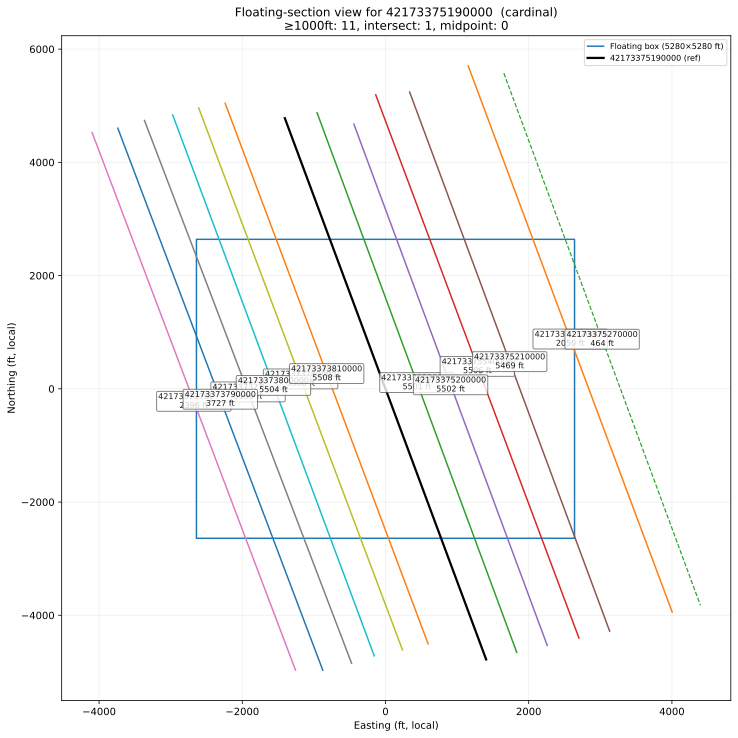

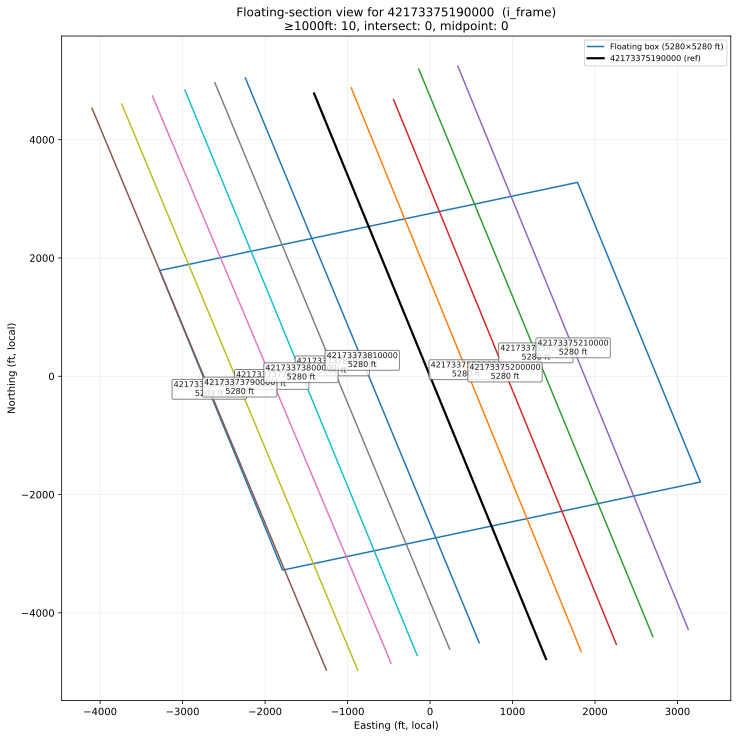

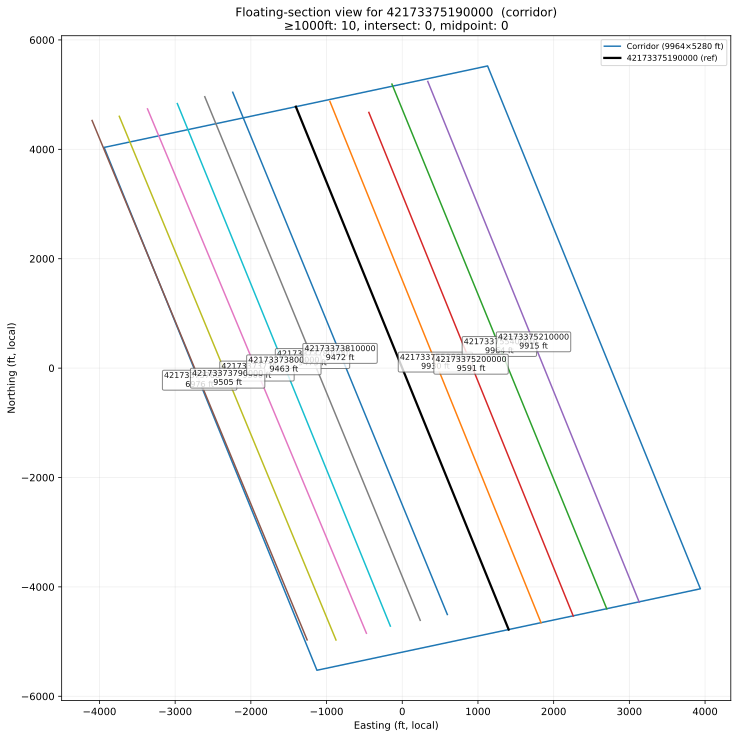

In [38]:
uwi = "42173375190000"

# Cardinal floating-section view
fig = wps.visualize(uwi, orientation="cardinal", figsize=(12,12))

# I-frame view (box aligned to reference lateral)
fig_if = wps.visualize(uwi, orientation="i_frame", min_len_ft=1000, figsize=(12,12))

fig_corr = wps.visualize(uwi, orientation="corridor", min_len_ft=1000, figsize=(12,12))

## 8. Production

### 8.1 Reading Production Data from file

In [39]:
df_prod_raw = read_csv_with_mapper(
    path=r"C:\Users\ApoorvaSaxen_ct6z7vh\OneDrive - Bandera Group\Desktop\Project AP\05. Spacing Study\02. TPL\03. Production\monthly_prod.csv",
    col_map={
        "API_UWI_14_Unformatted":"uwi", "ProducingMonth":"prod_date",
        "LiquidsProd_BBL": "monthly_oil_bbl", "GasProd_MCF": "monthly_gas_mcf",
        "WaterProd_BBL": "monthly_water_bbl"
        },
    parse_dates=["ProducingMonth"],
    dtype_map={"uwi": "string", "API_UWI_Unformatted": "string"}
)

### 8.2 Standardizing Column Names

In [40]:
df_prod_standardize = standardize_column_names(df_prod_raw)

### 8.3 Calculating Producing Months

In [41]:
df_prod_standardize = add_producing_months(df=df_prod_standardize, date_col="prod_date", uwi_col="uwi", out_col="producing_months_calc")

In [42]:
# Reorder columns to place 'producing_months_calc' after 'prod_date'
df_prod_standardize = reorder_columns(df=df_prod_standardize, columns_to_move=["monthly_oil_bbl", "monthly_gas_mcf","monthly_water_bbl", "prod_date", "producing_months_calc"], reference_column="uwi")

### 8.4 Merging Lateral Length

In [43]:
# Merge lateral length into production dataframe
df_prod_standardize = df_prod_standardize.merge(df_header_filter_for_spacing[['uwi', 'lateral_length_ft']], on='uwi', how='left')

### 8.5 Calculating Cumulative Volumes by Period (180 & 365 days)

In [44]:
df_uwi_180_365d_cum = calculate_cumulative_volumes_by_period(df_prod_standardize, oil_col='monthly_oil_bbl',gas_col='monthly_gas_mcf',water_col='monthly_water_bbl', lateral_length_col='lateral_length_ft')

In [45]:
df_uwi_180_365d_cum

,uwi,lateral_length_ft,cum_oil_180d,cum_gas_180d,cum_water_180d,cum_oil_365d,cum_gas_365d,cum_water_365d,cum_oil_180d_per_ft,cum_gas_180d_per_ft,cum_water_180d_per_ft,cum_oil_365d_per_ft,cum_gas_365d_per_ft,cum_water_365d_per_ft
0,42173006330100,918.299988,4885.00,1138.00,0.00,9080.0,9831.00,0.00,5.319612,1.239246,0.000000,9.887836,10.705652,0.000000
1,42173319360100,1857.197754,18286.84,21291.62,0.00,37718.4,39158.72,0.00,9.846469,11.464380,0.000000,20.309307,21.084841,0.000000
2,42173322810000,NaN,47498.00,53259.00,0.00,121342.0,117355.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN
3,42173328120000,1074.000000,9505.00,16408.00,0.00,17125.0,21550.00,0.00,8.850093,15.277467,0.000000,15.945065,20.065177,0.000000
4,42173334750000,3721.000000,9923.00,27277.00,1818.79,14481.0,50987.00,2967.44,2.666756,7.330556,0.488791,3.891696,13.702499,0.797485
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17323,42329476710000,10066.000000,11960.00,13092.00,0.00,11960.0,13092.00,0.00,1.188158,1.300616,0.000000,1.188158,1.300616,0.000000
17324,42329476740000,10476.000000,13512.00,13673.00,32713.60,13512.0,13673.00,32713.60,1.289805,1.305174,3.122719,1.289805,1.305174,3.122719
17325,42329476760000,3811.000000,10994.00,10856.00,0.00,10994.0,10856.00,0.00,2.884807,2.848596,0.000000,2.884807,2.848596,0.000000
17326,42329476820000,10471.000000,24527.00,25011.00,0.00,24527.0,25011.00,0.00,2.342374,2.388597,0.000000,2.342374,2.388597,0.000000


## 9. Final Merge

### 9.1 Merging WPS summary dataframe with Cumulative Volumes dataframe

In [46]:
df_cum_merge_wps = df_uwi_180_365d_cum.merge(df_wps_summary[['well_i', 'wps_cardinal', 'wps_iframe', 'wps_corridor']].rename(columns={"well_i": "uwi"}), on='uwi', how='left').drop(columns=["lateral_length_ft"]).reset_index(drop=True)

In [47]:
df_cum_merge_wps

,uwi,cum_oil_180d,cum_gas_180d,cum_water_180d,cum_oil_365d,cum_gas_365d,cum_water_365d,cum_oil_180d_per_ft,cum_gas_180d_per_ft,cum_water_180d_per_ft,cum_oil_365d_per_ft,cum_gas_365d_per_ft,cum_water_365d_per_ft,wps_cardinal,wps_iframe,wps_corridor
0,42173006330100,4885.00,1138.00,0.00,9080.0,9831.00,0.00,5.319612,1.239246,0.000000,9.887836,10.705652,0.000000,1.0,1.0,0.0
1,42173319360100,18286.84,21291.62,0.00,37718.4,39158.72,0.00,9.846469,11.464380,0.000000,20.309307,21.084841,0.000000,27.0,26.0,24.0
2,42173322810000,47498.00,53259.00,0.00,121342.0,117355.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,28.0,29.0,1.0
3,42173328120000,9505.00,16408.00,0.00,17125.0,21550.00,0.00,8.850093,15.277467,0.000000,15.945065,20.065177,0.000000,1.0,1.0,1.0
4,42173334750000,9923.00,27277.00,1818.79,14481.0,50987.00,2967.44,2.666756,7.330556,0.488791,3.891696,13.702499,0.797485,4.0,3.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17323,42329476710000,11960.00,13092.00,0.00,11960.0,13092.00,0.00,1.188158,1.300616,0.000000,1.188158,1.300616,0.000000,35.0,35.0,35.0
17324,42329476740000,13512.00,13673.00,32713.60,13512.0,13673.00,32713.60,1.289805,1.305174,3.122719,1.289805,1.305174,3.122719,28.0,28.0,14.0
17325,42329476760000,10994.00,10856.00,0.00,10994.0,10856.00,0.00,2.884807,2.848596,0.000000,2.884807,2.848596,0.000000,15.0,15.0,8.0
17326,42329476820000,24527.00,25011.00,0.00,24527.0,25011.00,0.00,2.342374,2.388597,0.000000,2.342374,2.388597,0.000000,30.0,28.0,15.0


### 9.2 Merge df_cum_merge_wps dataframe with header

In [48]:
df_header_final_spacing = df_header_filter_for_spacing.merge(df_cum_merge_wps, on='uwi', how='left')

### 9.3 Merge df_utm_lateral dataframe with header to get final header data that will go to Spotfire

In [49]:
df_header_final_spacing = df_header_final_spacing.merge(df_utm_lateral.groupby('uwi')['tvd'].agg('mean').reset_index(), on='uwi', how='left')

In [50]:
df_header_final_spacing

,uwi,uwi12,lease_name,well_name,operator,bench,bg_rcat,spud_date,comp_date,first_prod_date,last_prod_date,hole_direction,well_status,lateral_length_ft,surface_lat,surface_lon,fluid_intensity_bbl_per_ft,proppant_intensity_lbs_per_ft,cum_oil_180d,cum_gas_180d,cum_water_180d,cum_oil_365d,cum_gas_365d,cum_water_365d,cum_oil_180d_per_ft,cum_gas_180d_per_ft,cum_water_180d_per_ft,cum_oil_365d_per_ft,cum_gas_365d_per_ft,cum_water_365d_per_ft,wps_cardinal,wps_iframe,wps_corridor,tvd
0,42329467950000,423294679500,MCALISTER 33I,MCALISTER 33I 9H,EXXON,WOLFCAMP B UPPER,1PDP,2024-04-06 00:00:00+00:00,2024-10-19 00:00:00+00:00,2024-10-01 00:00:00+00:00,2025-11-01 00:00:00+00:00,HORIZONTAL,PRODUCING,9852.000000,32.055420,-101.915950,40.815063,2131.456543,81779.00,102788.00,234477.09,128873.00,228373.00,387338.67,8.300751,10.433212,23.799948,13.080897,23.180369,39.315740,18.0,16.0,17.0,9244.513458
1,42227425010000,422274250100,DIREWOLF UNIT 16-28,DIREWOLF UNIT 16-28 3SH,SURGE OPERATING,LOWER SPRABERRY,1PDP,2024-07-06 00:00:00+00:00,2024-12-21 00:00:00+00:00,2024-12-01 00:00:00+00:00,2025-11-01 00:00:00+00:00,HORIZONTAL,PRODUCING,11355.000000,32.324681,-101.460633,33.629066,1964.792603,66850.96,74337.45,254784.99,121410.21,189811.42,480426.38,5.887359,6.546671,22.438132,10.692225,16.716109,42.309677,14.0,12.0,12.0,6937.761673
2,42227389800000,422273898000,W H 48 UNIT,W H 48 UNIT 1LS,DIAMONDBACK,LOWER SPRABERRY,1PDP,2017-02-03 00:00:00+00:00,2017-06-22 00:00:00+00:00,2017-07-01 00:00:00+00:00,2025-11-01 00:00:00+00:00,HORIZONTAL,PRODUCING,7320.350098,32.450677,-101.657990,41.563572,1596.927002,56949.00,96294.38,51776.72,83382.56,140897.41,79569.50,7.779546,13.154341,7.072984,11.390515,19.247360,10.869630,25.0,21.0,24.0,7913.304444
3,42329461180000,423294611800,TEX-HARVEY SPRABERRY,TEX-HARVEY SPRABERRY 2255,DIAMONDBACK,JO MILL,1PDP,2023-08-10 00:00:00+00:00,2024-07-08 00:00:00+00:00,2024-07-01 00:00:00+00:00,2025-11-01 00:00:00+00:00,HORIZONTAL,PRODUCING,9950.000000,31.862318,-101.833295,43.639694,1606.783813,98018.69,264826.83,492169.87,161140.18,624391.84,828579.19,9.851125,26.615762,49.464309,16.194993,62.752949,83.274290,33.0,29.0,30.0,7958.919352
4,42329461460000,423294614600,MIDWAY 2-35 C,MIDWAY 2-35 C 137,DIAMONDBACK,MIDDLE SPRABERRY,1PDP,2023-04-11 00:00:00+00:00,2023-10-09 00:00:00+00:00,2023-10-01 00:00:00+00:00,2025-11-01 00:00:00+00:00,HORIZONTAL,PRODUCING,10508.000000,31.973446,-101.873058,44.031094,1598.698364,2437.44,3131.98,99171.30,3481.25,5700.28,141630.34,0.231960,0.298057,9.437695,0.331295,0.542470,13.478335,39.0,34.0,39.0,7649.719752
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18834,42329463090000,423294630900,MBE,MBE 701H,FIREBIRD ENERGY II LLC,WOLFCAMP B LOWER,1PDP,2024-09-04 00:00:00+00:00,2025-05-16 00:00:00+00:00,2025-06-01 00:00:00+00:00,2025-10-01 00:00:00+00:00,HORIZONTAL,PRODUCING,7908.000000,32.039697,-102.160811,54.099773,2258.340576,96983.00,133899.00,0.00,96983.00,133899.00,0.00,12.263910,16.932094,0.000000,12.263910,16.932094,0.000000,30.0,26.0,27.0,9780.370640
18835,42329447180000,423294471800,A.B. HARRINGTON H2,A.B. HARRINGTON H2 608LH,CONOCOPHILLIPS,LOWER SPRABERRY,1PDP,2021-04-22 00:00:00+00:00,2022-03-18 00:00:00+00:00,2022-03-01 00:00:00+00:00,2025-10-01 00:00:00+00:00,HORIZONTAL,PRODUCING,15756.000000,31.836651,-102.188913,61.588135,2470.182129,65797.00,49294.00,294826.57,147298.00,107880.00,598184.98,4.175996,3.128586,18.712019,9.348693,6.846915,37.965536,9.0,8.0,13.0,9114.223160
18836,42173392270000,421733922700,FLINTLOCK E,FLINTLOCK E 11JM,OCCIDENTAL,JO MILL,2DUC,2025-11-26 00:00:00+00:00,NaN,NaN,NaN,HORIZONTAL,DUC,9898.000000,31.831036,-101.703714,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8497.376856
18837,42317471340000,423174713400,CURTIS-SCHARBAUER 8C,CURTIS-SCHARBAUER 8C 3H,EXXON,WOLFCAMP C,2DUC,2026-01-19 00:00:00+00:00,NaN,NaN,NaN,HORIZONTAL,SPUD DATE ONLY,10619.083008,32.246